
Training RNN model...
Epoch 1/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 52s 64ms/step - accuracy: 0.6394 - loss: 0.6168 - val_accuracy: 0.6401 - val_loss: 0.6761
Epoch 2/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 47s 60ms/step - accuracy: 0.7041 - loss: 0.5731 - val_accuracy: 0.6780 - val_loss: 0.5912
Epoch 3/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 48s 61ms/step - accuracy: 0.7781 - loss: 0.4726 - val_accuracy: 0.7678 - val_loss: 0.4960
Epoch 4/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 82s 61ms/step - accuracy: 0.8492 - loss: 0.3554 - val_accuracy: 0.7452 - val_loss: 0.5119
Epoch 5/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 48s 61ms/step - accuracy: 0.8214 - loss: 0.4017 - val_accuracy: 0.7428 - val_loss: 0.5749

Training LSTM model...
Epoch 1/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 101s 126ms/step - accuracy: 0.7943 - loss: 0.4388 - val_accuracy: 0.8494 - val_loss: 0.3495
Epoch 2/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 141s 125ms/step - accuracy: 0.8944 - loss: 0.2630 - val_accuracy: 0.8662 - val_loss: 0.3150
Epoch 3/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 143s 12

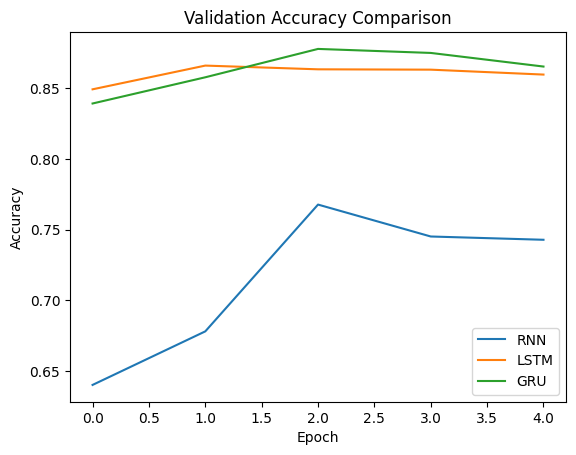

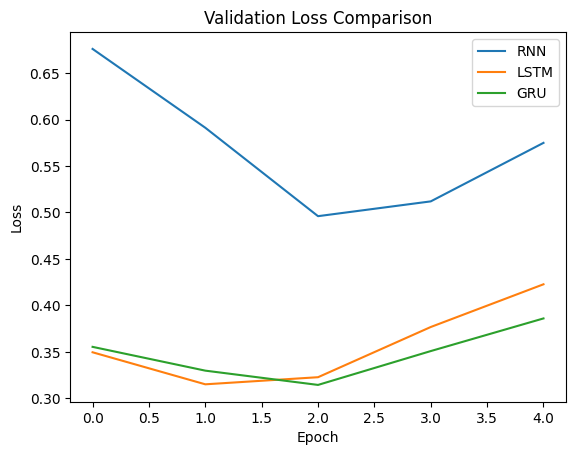

In [ ]:
# Import Libraries
import tensorflow as tf
from tensorflow.keras import datasets, layers, models
import matplotlib.pyplot as plt

# 1. Load IMDb Dataset
vocab_size = 10000
max_len = 200

(x_train, y_train), (x_test, y_test) = datasets.imdb.load_data(num_words=vocab_size)

# Pad sequences
x_train = tf.keras.preprocessing.sequence.pad_sequences(x_train, maxlen=max_len)
x_test = tf.keras.preprocessing.sequence.pad_sequences(x_test, maxlen=max_len)

# Function to build models
def build_model(model_type):
    model = models.Sequential()
    model.add(layers.Embedding(vocab_size, 64, input_length=max_len))

    if model_type == "RNN":
        model.add(layers.SimpleRNN(64))
    elif model_type == "LSTM":
        model.add(layers.LSTM(64))
    elif model_type == "GRU":
        model.add(layers.GRU(64))

    model.add(layers.Dense(1, activation='sigmoid'))

    model.compile(optimizer='adam',
                  loss='binary_crossentropy',
                  metrics=['accuracy'])
    return model

# 2. Train Models
histories = {}

for model_type in ["RNN", "LSTM", "GRU"]:
    print(f"\nTraining {model_type} model...")
    model = build_model(model_type)

    history = model.fit(x_train, y_train,
                        epochs=5,
                        batch_size=32,
                        validation_data=(x_test, y_test),
                        verbose=1)

    histories[model_type] = history

# 3. Plot Accuracy Comparison
plt.figure()

for model_type in histories:
    plt.plot(histories[model_type].history['val_accuracy'], label=model_type)

plt.title("Validation Accuracy Comparison")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

# 4. Plot Loss Comparison
plt.figure()

for model_type in histories:
    plt.plot(histories[model_type].history['val_loss'], label=model_type)

plt.title("Validation Loss Comparison")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()